In [ ]:
import pandas as pd # Import the libraries required for sparse preprocessing, model training, and performance evaluation.
import ast
import joblib

from sklearn.preprocessing import (
    MultiLabelBinarizer,
    LabelEncoder
)

from scipy.sparse import hstack, csr_matrix

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

In [ ]:
train_df = pd.read_csv("/content/ddxplus/train.csv") # Load the DDXPlus training and validation datasets for XGBoost model training.
valid_df = pd.read_csv("/content/ddxplus/validate.csv")

In [ ]:
def preprocess_sparse(df, mlb=None, fit_mlb=False): # Define a sparse preprocessing pipeline to efficiently encode large-scale symptom evidence data.

    evidences = df['EVIDENCES'].apply(ast.literal_eval)

    sex = df['SEX'].map({
        'M': 0,
        'F': 1
    }).values.reshape(-1, 1)

    age = df['AGE'].values.reshape(-1, 1)

    if fit_mlb:
        evidence_sparse = mlb.fit_transform(evidences)
    else:
        evidence_sparse = mlb.transform(evidences)

    X = hstack([
        csr_matrix(age),
        csr_matrix(sex),
        csr_matrix(evidence_sparse)
    ])

    y = df['PATHOLOGY']

    return X, y

In [ ]:
mlb = MultiLabelBinarizer(sparse_output=True) # Transform the training and validation datasets into sparse machine learning feature matrices.

X_train, y_train = preprocess_sparse(
    train_df,
    mlb=mlb,
    fit_mlb=True
)

X_valid, y_valid = preprocess_sparse(
    valid_df,
    mlb=mlb,
    fit_mlb=False
)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['E_133_@_V_186'] will be ignored
  warnings.warn(


In [ ]:
label_encoder = LabelEncoder() # Encode disease labels into numerical classes for XGBoost model training and evaluation.

y_train_encoded = label_encoder.fit_transform(y_train)
y_valid_encoded = label_encoder.transform(y_valid)

In [ ]:
xgb_model = XGBClassifier( # Configure the XGBoost classifier with optimized hyperparameters for multiclass disease prediction.
    objective='multi:softmax',

    num_class=len(label_encoder.classes_),

    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,

    tree_method='hist',

    random_state=42,
    n_jobs=-1
)

In [ ]:
xgb_model.fit(X_train, y_train_encoded) # Train the XGBoost classifier using the sparse preprocessed training dataset.

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_class=49, ...)

In [ ]:
xgb_pred = xgb_model.predict(X_valid) # Generate disease predictions on the validation dataset using the trained XGBoost model.

In [ ]:
xgb_accuracy = accuracy_score( # Evaluate the XGBoost model using multiclass classification performance metrics.
    y_valid_encoded,
    xgb_pred
)

xgb_precision = precision_score(
    y_valid_encoded,
    xgb_pred,
    average='weighted'
)

xgb_recall = recall_score(
    y_valid_encoded,
    xgb_pred,
    average='weighted'
)

xgb_f1 = f1_score(
    y_valid_encoded,
    xgb_pred,
    average='weighted'
)

xgb_mcc = matthews_corrcoef(
    y_valid_encoded,
    xgb_pred
)

print("XGBoost Results")
print("-" * 50)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")
print(f"MCC      : {xgb_mcc:.4f}")

XGBoost Results
--------------------------------------------------
Accuracy : 0.9971
Precision: 0.9973
Recall   : 0.9971
F1-Score : 0.9971
MCC      : 0.9970


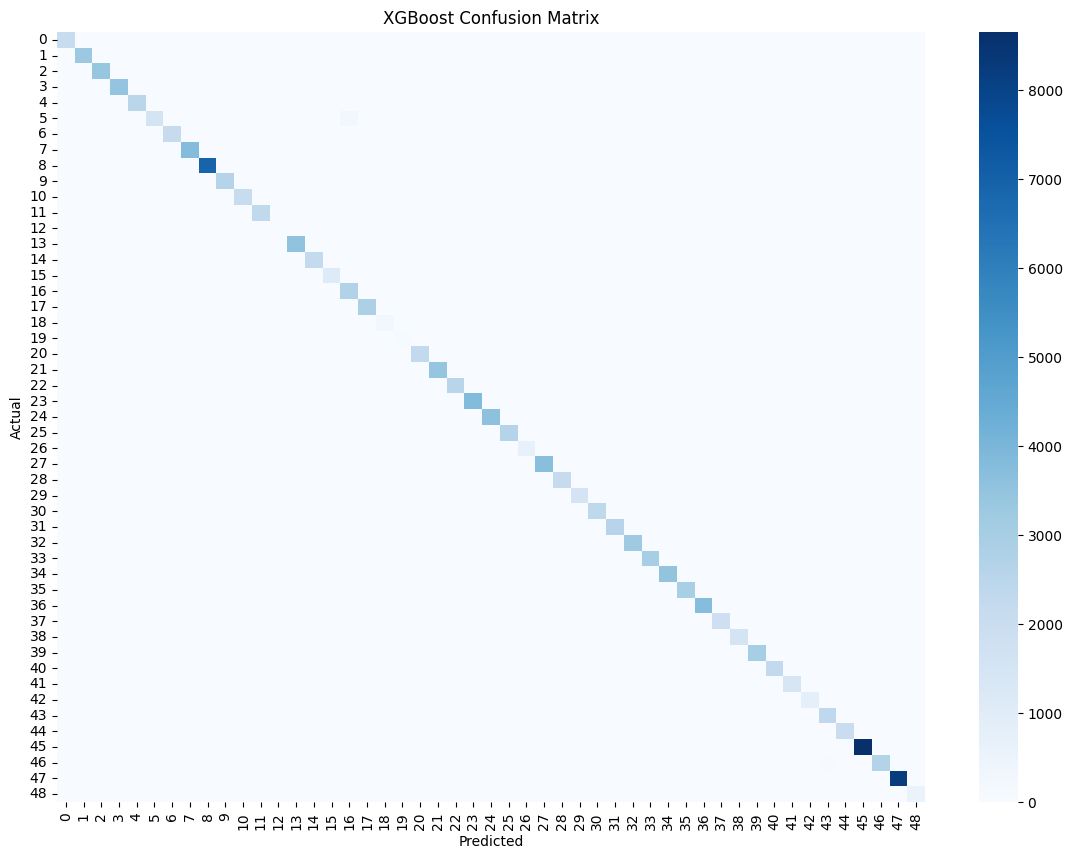

In [ ]:
from sklearn.metrics import confusion_matrix # Visualize the classification performance of the XGBoost model using a confusion matrix heatmap.
import matplotlib.pyplot as plt
import seaborn as sns

xgb_cm = confusion_matrix(
    y_valid_encoded,
    xgb_pred
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    xgb_cm,
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("xgboost_confusion_matrix.png")

plt.show()

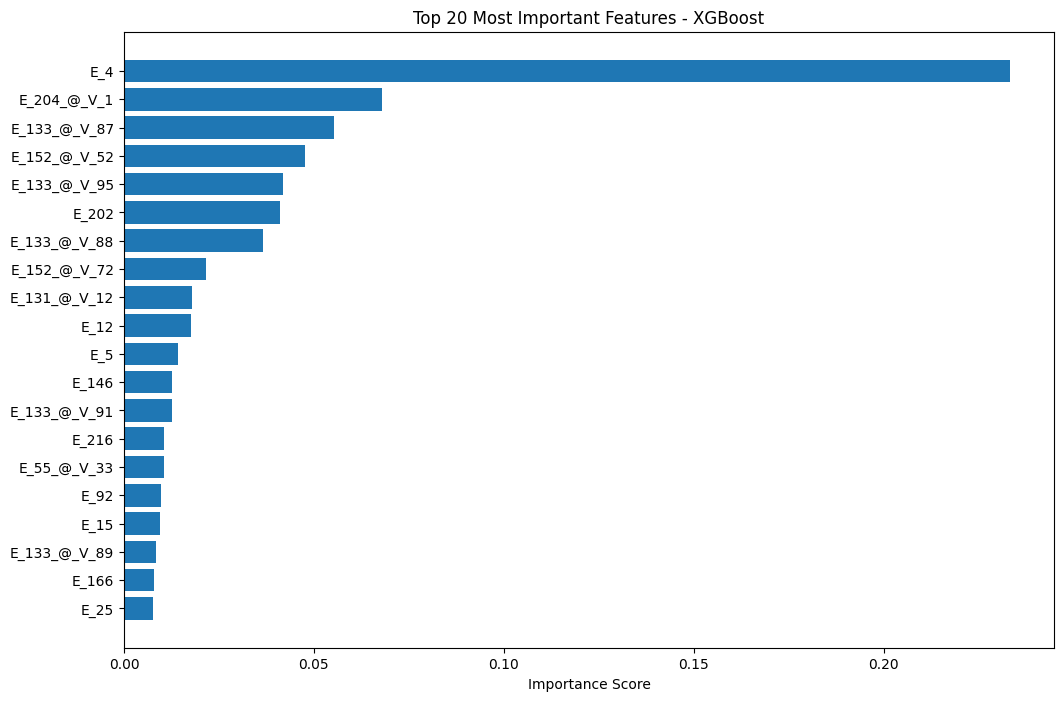

In [ ]:
import numpy as np # Visualize the most influential symptom evidence features used by the XGBoost model for disease prediction.

feature_names = (
    ['AGE', 'SEX']
    + list(mlb.classes_)
)

importances = xgb_model.feature_importances_

indices = np.argsort(importances)[-20:]

plt.figure(figsize=(12,8))

plt.barh(
    range(len(indices)),
    importances[indices]
)

plt.yticks(
    range(len(indices)),
    [feature_names[i] for i in indices]
)

plt.title("Top 20 Most Important Features - XGBoost")
plt.xlabel("Importance Score")

plt.savefig("xgboost_feature_importance.png")

plt.show()

In [ ]:
xgb_results_df = pd.DataFrame([{ # Store the XGBoost evaluation metrics in a structured dataframe for model comparison and reporting.
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1,
    "MCC": xgb_mcc
}])

xgb_results_df

,Model,Accuracy,Precision,Recall,F1 Score,MCC
0,XGBoost,0.997116,0.99734,0.997116,0.997077,0.997037
